In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style
sns.set_theme(style="whitegrid")
%matplotlib inline

# Load data
df = pd.read_csv('../data/raw/daily_inventory.csv')
df['date'] = pd.to_datetime(df['date'])

print(f"Data shape: {df.shape}")


Data shape: (35040, 15)


In [2]:

print("=== Summary ===")
print(f"Date Range: {df['date'].min()} to {df['date'].max()}")
print(f"Hospitals: {df['hospital_id'].unique()}")
print(f"Blood Types: {df['blood_type'].unique()}")
print("\nBlood Type Distribution:")
print(df['blood_type'].value_counts())


=== Summary ===
Date Range: 2023-01-01 00:00:00 to 2024-12-30 00:00:00
Hospitals: ['H1' 'H2' 'H3' 'H4' 'H5' 'H6']
Blood Types: ['O+' 'O-' 'A+' 'A-' 'B+' 'B-' 'AB+' 'AB-']

Blood Type Distribution:
blood_type
O+     4380
O-     4380
A+     4380
A-     4380
B+     4380
B-     4380
AB+    4380
AB-    4380
Name: count, dtype: int64


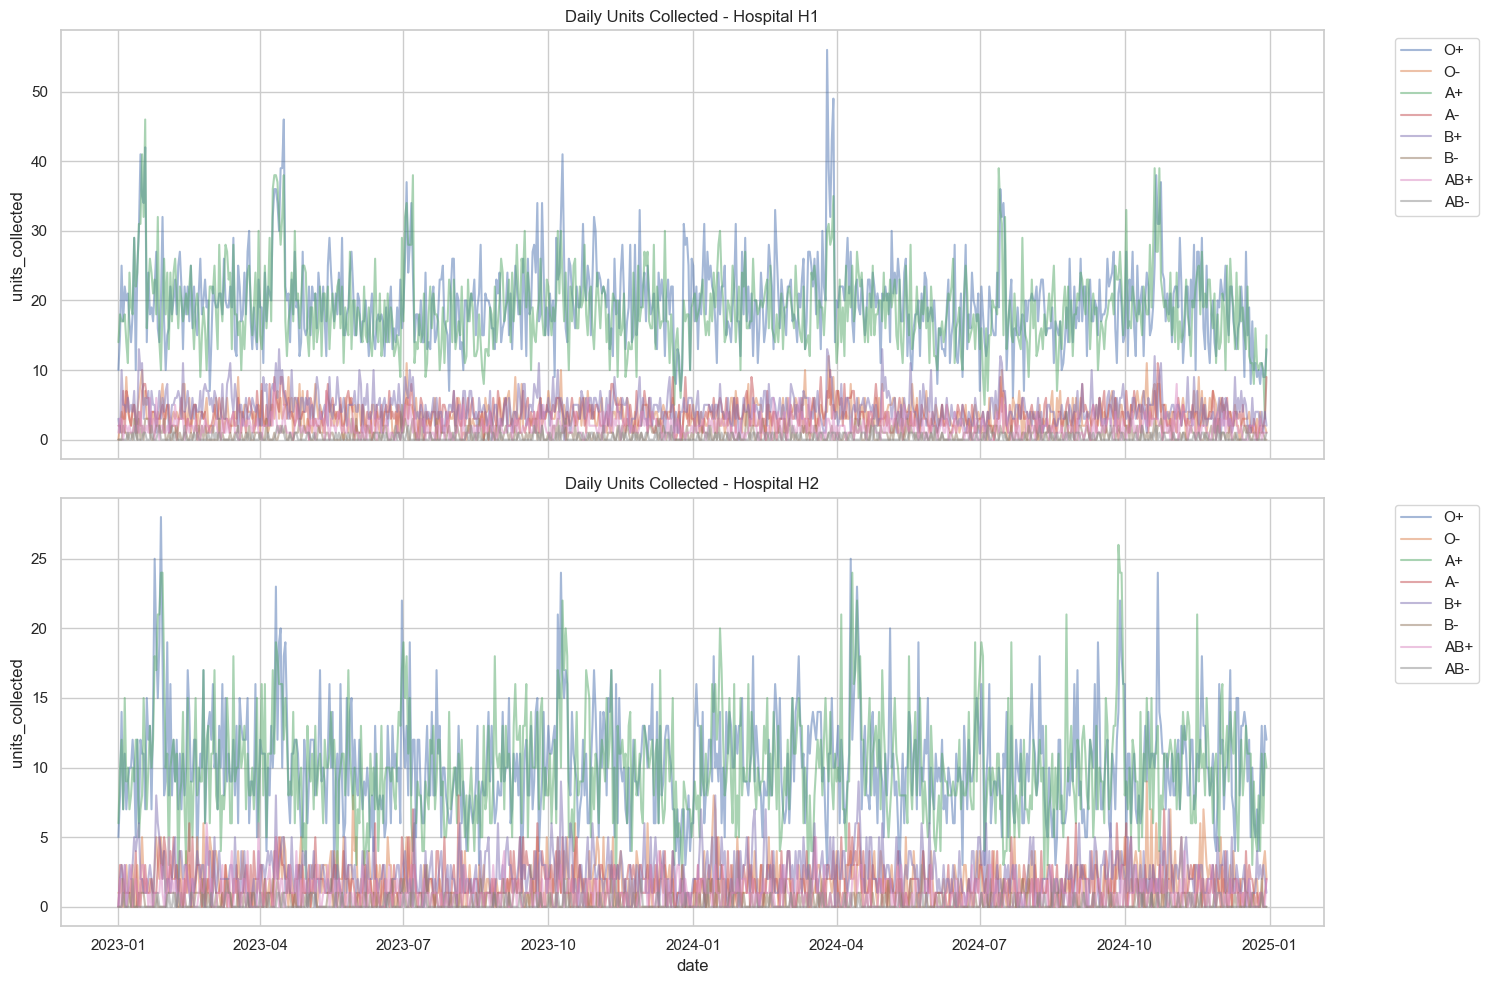

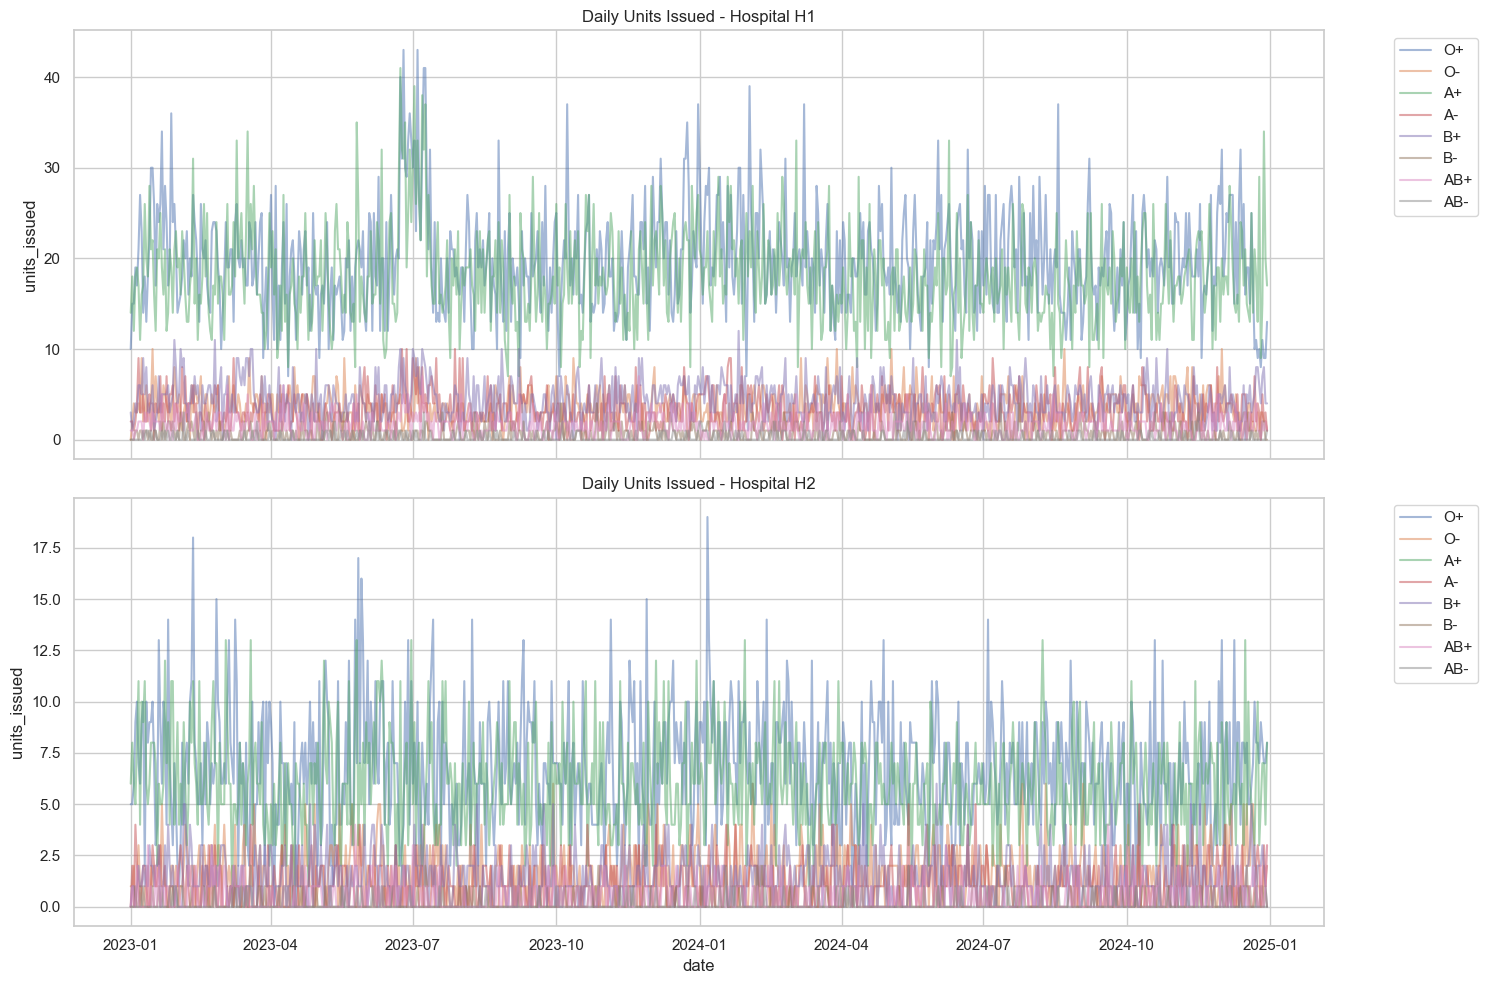

In [3]:

hospitals = df['hospital_id'].unique()[:2]
fig, axes = plt.subplots(len(hospitals), 1, figsize=(15, 10), sharex=True)

for i, h_id in enumerate(hospitals):
    h_data = df[df['hospital_id'] == h_id]
    sns.lineplot(data=h_data, x='date', y='units_collected', hue='blood_type', ax=axes[i], alpha=0.5)
    axes[i].set_title(f"Daily Units Collected - Hospital {h_id}")
    axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(len(hospitals), 1, figsize=(15, 10), sharex=True)

for i, h_id in enumerate(hospitals):
    h_data = df[df['hospital_id'] == h_id]
    sns.lineplot(data=h_data, x='date', y='units_issued', hue='blood_type', ax=axes[i], alpha=0.5)
    axes[i].set_title(f"Daily Units Issued - Hospital {h_id}")
    axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


/var/folders/l7/scszhw111rs9dr3syxcl3mf80000gn/T/ipykernel_14592/1861789798.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=wastage.index, y=wastage['wastage_pct'], palette='viridis')


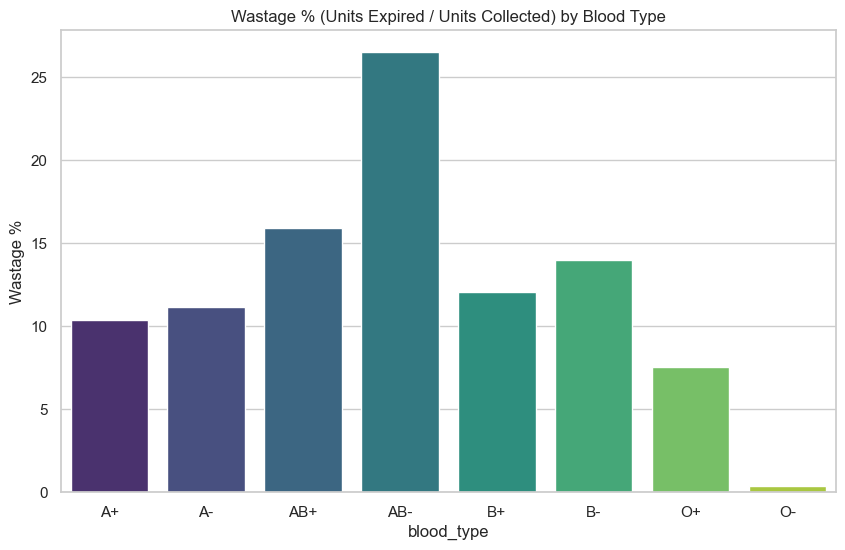

In [4]:

# Group by blood_type and calculate sums
wastage = df.groupby('blood_type')[['units_expired', 'units_collected']].sum()
wastage['wastage_pct'] = (wastage['units_expired'] / wastage['units_collected']) * 100

plt.figure(figsize=(10, 6))
sns.barplot(x=wastage.index, y=wastage['wastage_pct'], palette='viridis')
plt.title("Wastage % (Units Expired / Units Collected) by Blood Type")
plt.ylabel("Wastage %")
plt.show()


/var/folders/l7/scszhw111rs9dr3syxcl3mf80000gn/T/ipykernel_14592/1310480739.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=shortage_freq_bt.index, y=shortage_freq_bt.values, ax=ax1, palette='magma')
/var/folders/l7/scszhw111rs9dr3syxcl3mf80000gn/T/ipykernel_14592/1310480739.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=shortage_freq_h.index, y=shortage_freq_h.values, ax=ax2, palette='coolwarm')


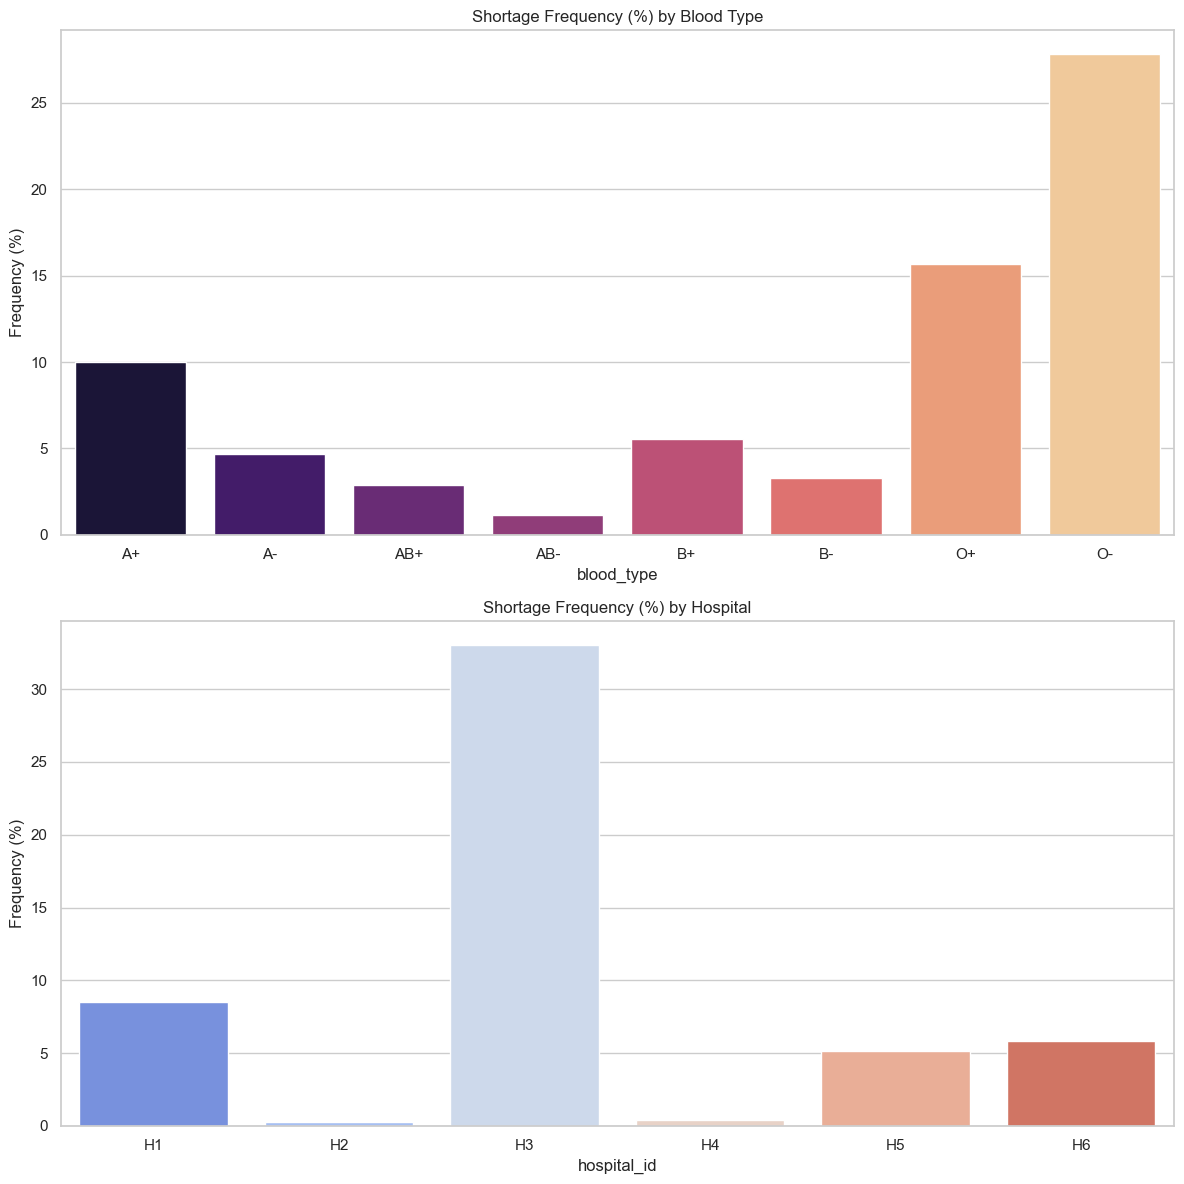

In [5]:

df['has_shortage'] = df['shortage_units'] > 0

shortage_freq_bt = df.groupby('blood_type')['has_shortage'].mean() * 100
shortage_freq_h = df.groupby('hospital_id')['has_shortage'].mean() * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

sns.barplot(x=shortage_freq_bt.index, y=shortage_freq_bt.values, ax=ax1, palette='magma')
ax1.set_title("Shortage Frequency (%) by Blood Type")
ax1.set_ylabel("Frequency (%)")

sns.barplot(x=shortage_freq_h.index, y=shortage_freq_h.values, ax=ax2, palette='coolwarm')
ax2.set_title("Shortage Frequency (%) by Hospital")
ax2.set_ylabel("Frequency (%)")

plt.tight_layout()
plt.show()


/var/folders/l7/scszhw111rs9dr3syxcl3mf80000gn/T/ipykernel_14592/543187192.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=flag, y='units_demanded', ax=axes[i], palette='muted')


/var/folders/l7/scszhw111rs9dr3syxcl3mf80000gn/T/ipykernel_14592/543187192.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=flag, y='units_demanded', ax=axes[i], palette='muted')


/var/folders/l7/scszhw111rs9dr3syxcl3mf80000gn/T/ipykernel_14592/543187192.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=flag, y='units_demanded', ax=axes[i], palette='muted')


/var/folders/l7/scszhw111rs9dr3syxcl3mf80000gn/T/ipykernel_14592/543187192.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=flag, y='units_demanded', ax=axes[i], palette='muted')


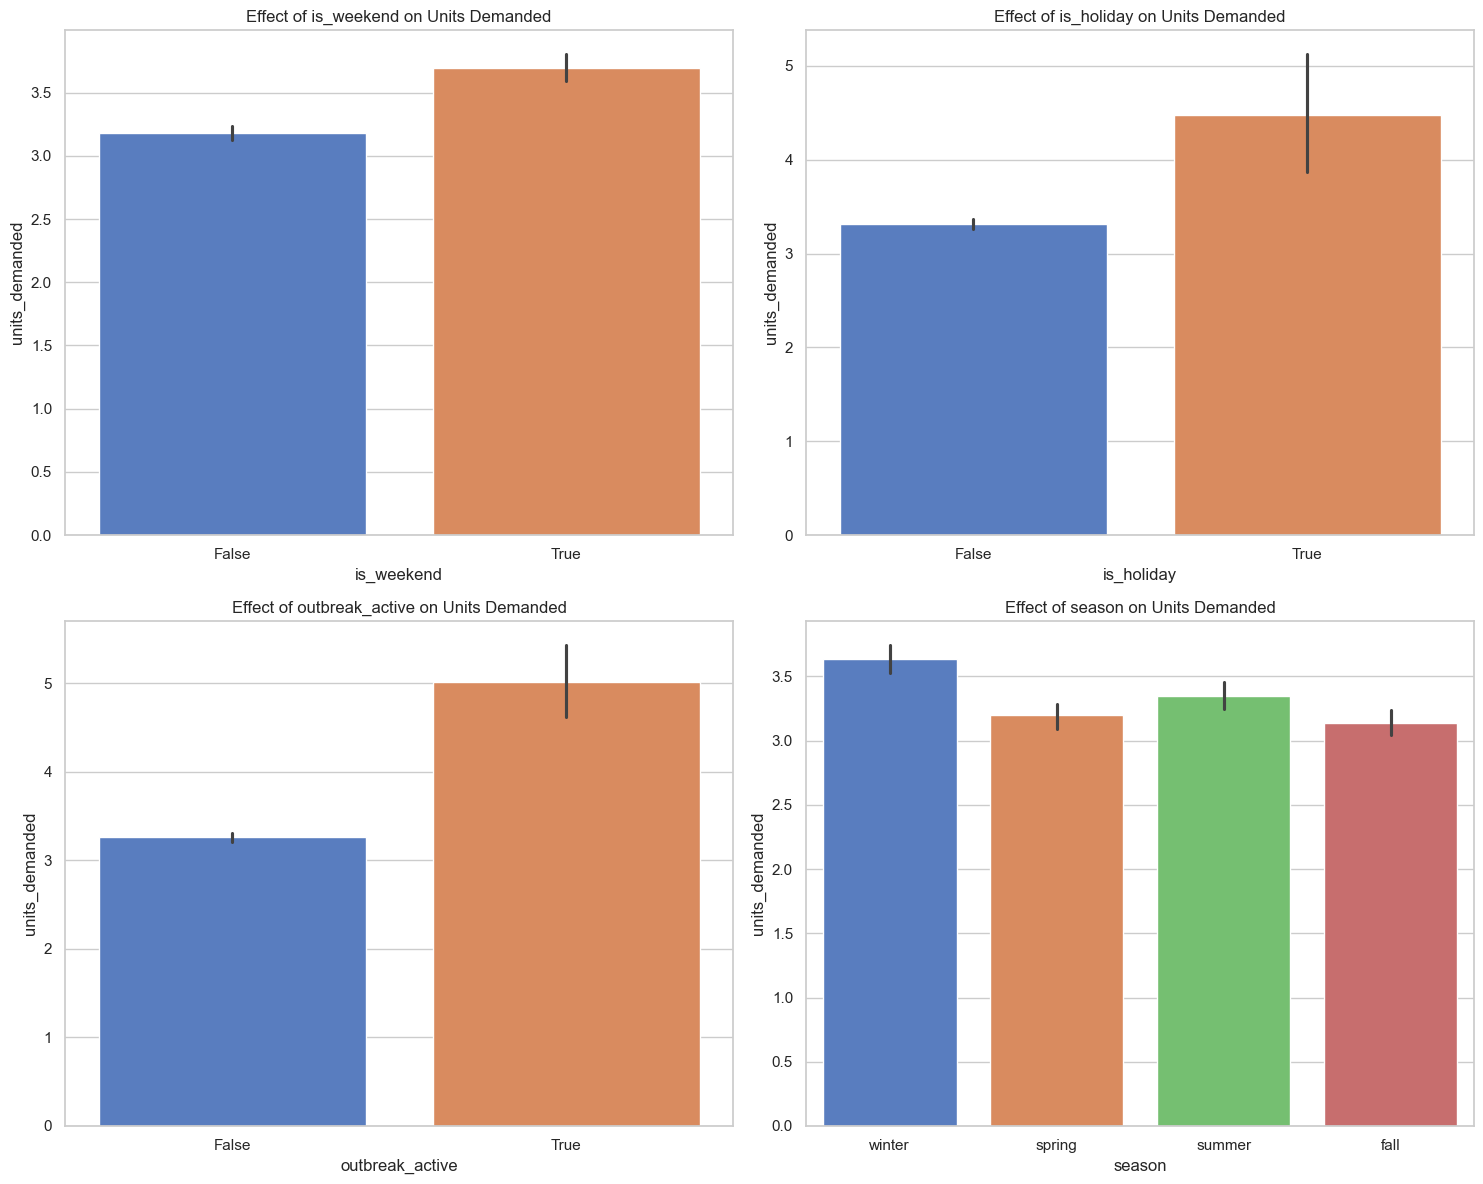

Mean demand (is_weekend): {False: 3.182941458733205, True: 3.696969696969697}
Mean demand (is_holiday): {False: 3.31585182616736, True: 4.472222222222222}
Mean demand (outbreak_active): {False: 3.2614338322641956, True: 5.02046783625731}


In [6]:

flags = ['is_weekend', 'is_holiday', 'outbreak_active', 'season']
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, flag in enumerate(flags):
    sns.barplot(data=df, x=flag, y='units_demanded', ax=axes[i], palette='muted')
    axes[i].set_title(f"Effect of {flag} on Units Demanded")

plt.tight_layout()
plt.show()

# Print mean comparison table
for flag in flags[:-1]: # skip season for binary flags
    means = df.groupby(flag)['units_demanded'].mean()
    print(f"Mean demand ({flag}): {means.to_dict()}")
